In [1]:
import anndata as ad
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore
from scipy.cluster.hierarchy import linkage, dendrogram

from scipy.spatial import KDTree

import squidpy as sq
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
sns.set_context('notebook')

## TASK 1

In [2]:

DATA_PATH = 'data/train_adata.h5ad'
adata = ad.read_h5ad(DATA_PATH)


# 1. 

n_cells = adata.n_obs
n_markers = adata.n_vars
n_images = adata.obs['image'].nunique()
n_indications = adata.obs['Indication'].nunique()

indication_counts = adata.obs['Indication'].value_counts()
summary_table = pd.DataFrame({
    "Metric": [
        "Number of cells",
        "Number of markers",
        "Number of images",
        "Number of cancer indications"
    ],
    "Value": [
        n_cells,
        n_markers,
        n_images,
        n_indications
    ]
})

indication_table = indication_counts.reset_index()
indication_table.columns = ["Cancer indication", "Cell count"]


print("\n=== DATASET SUMMARY ===")
display(summary_table)


print("\n=== VALUE COUNTS OF CANCER INDICATIONS")
display(indication_table)


# 2. CELL TYPE COUNTS

celltype_counts = adata.obs['celltypes'].value_counts().sort_values(ascending=False)

celltype_table = celltype_counts.reset_index()
celltype_table.columns = ["Cell type", "Cell count"]

print("\n=== CELL TYPE COUNTS (sorted) ===")
display(celltype_table)


# 3. TUMOR FRACTION

tumor_cells = (adata.obs['celltypes'] == "Tumor").sum()

# 3. fraction
tumor_fraction = tumor_cells / n_cells

print(f"Tumor fraction: {tumor_fraction*100:.1f}%")



=== DATASET SUMMARY ===


,Metric,Value
0,Number of cells,253433
1,Number of markers,40
2,Number of images,132
3,Number of cancer indications,5



=== VALUE COUNTS OF CANCER INDICATIONS


,Cancer indication,Cell count
0,BREAS,67478
1,HN,52469
2,THOR,47966
3,GU,43720
4,GI,41800



=== CELL TYPE COUNTS (sorted) ===


,Cell type,Cell count
0,Tumor,138266
1,CD8,22722
2,Mural,20537
3,MacCD163,15288
4,CD4,13238
5,plasma,7872
6,Neutrophil,7386
7,BnT,6493
8,Treg,6381
9,DC,4921


Tumor fraction: 54.6%


## TASK 2

In [3]:
print(f"Cells  (n_obs) : {adata.n_obs:,}")
print(f"Markers (n_vars): {adata.n_vars}")
print(f"Images          : {adata.obs['image'].nunique()}")

Cells  (n_obs) : 253,433
Markers (n_vars): 40
Images          : 132


In [4]:
max_val  = adata.layers['exprs'].max()
mean_val = adata.layers['exprs'].mean()

print("Checking transformation status of 'exprs' layer:")
print(f"  max  : {max_val:.3f}")
print(f"  mean : {mean_val:.3f}")
print()

if max_val < 15:
    print("CONCLUSION: 'exprs' is ALREADY arcsinh(x/5)-transformed.")
    print(f"  max ≈ {max_val:.1f}  →  raw counts up to sinh({max_val:.1f})×5 ≈ {np.sinh(max_val)*5:,.0f}")
    print("  Do NOT apply arcsinh again — that would double-transform the data.")
else:
    print("CONCLUSION: 'exprs' appears to be raw (max >> 15). Apply arcsinh(x/5).")

Checking transformation status of 'exprs' layer:
  max  : 8.436
  mean : 1.381

CONCLUSION: 'exprs' is ALREADY arcsinh(x/5)-transformed.
  max ≈ 8.4  →  raw counts up to sinh(8.4)×5 ≈ 11,526
  Do NOT apply arcsinh again — that would double-transform the data.


In [5]:
# here we get the column numbers of the cells
col = [np.where((adata.var['marker'] == f'{mark}') & (adata.var['use_channel'] == 1))[0][0] for mark in ['Ecad', 'CD8a', 'Ki67']]

# isolate the corrisponding data for each of the markers
values =[]
for i in col:
    values.append(adata.layers['exprs'][:,i])

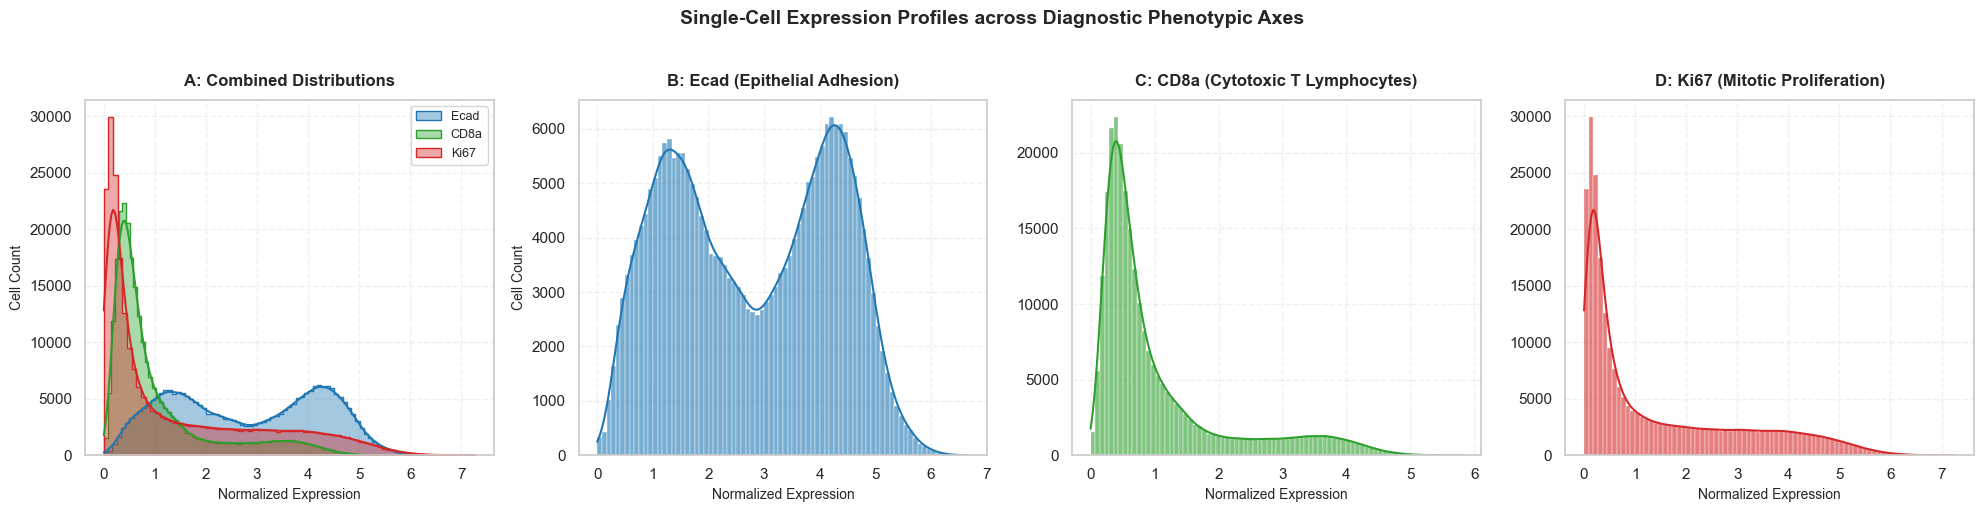

In [6]:
target_markers = ['Ecad', 'CD8a', 'Ki67']
palette = {'Ecad': '#1f77b4', 'CD8a': '#2ca02c', 'Ki67': '#d62728'}

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)

for i, marker in enumerate(target_markers):
    sns.histplot(
        data=values[i], 
        bins=80, 
        label=marker, 
        kde=True, 
            # kde = kernel density estimation
        alpha=0.4, 
        color=palette[marker],
        ax=axes[0],
        element="step"
    )
axes[0].set_title('A: Combined Distributions', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Normalized Expression', fontsize=10)
axes[0].set_ylabel('Cell Count', fontsize=10)
axes[0].legend(loc='upper right', frameon=True, fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.3)

for i, marker in enumerate(target_markers):
    current_ax = axes[i + 1]
    
    sns.histplot(
        data=values[i], 
        bins=80, 
        kde=True, 
        alpha=0.6, 
        color=palette[marker],
        ax=current_ax,
        element="bars"
    )
    
    functional_labels = {'Ecad': 'Epithelial Adhesion', 'CD8a': 'Cytotoxic T Lymphocytes', 'Ki67': 'Mitotic Proliferation'}
    
    current_ax.set_title(f'{chr(66 + i)}: {marker} ({functional_labels[marker]})', fontsize=12, fontweight='bold', pad=10)
    current_ax.set_xlabel('Normalized Expression', fontsize=10)
    current_ax.set_ylabel('Cell Count' if i == 0 else '', fontsize=10)  # Reduce redundant axis titles
    current_ax.grid(True, linestyle='--', alpha=0.3)

# Layout optimization to prevent title/label clipping
plt.suptitle('Single-Cell Expression Profiles across Diagnostic Phenotypic Axes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Clearly we can see that the epithelial cells (Ecad) have a bimodal distribution, however we can't be sure of the other two.

In [7]:
# checking the distribution modality 

from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
for i, marker in enumerate(['Ecad', 'CD8a', 'Ki67']):
    data=values[i]

    kde = gaussian_kde(data)

    x_grid = np.linspace(data.min(), data.max(), 1000)
    density = kde(x_grid)
    
    peaks, _ = find_peaks(density, distance=50, prominence=max(density)*0.02)
    # searches for local maxima
    
    is_bimodal = False
    num_peaks = len(peaks)
    
    if num_peaks >= 2:
        peaks = np.sort(peaks)
        
        region_pomiedzy = density[peaks[0]:peaks[1]]
        
        peak1_val = density[peaks[0]]
        peak2_val = density[peaks[1]]
        
        if np.min(region_pomiedzy) < (0.85 * min(peak1_val, peak2_val)):
            # okreslamy, ze w dystansie pomiedzy peak'ami wartosc musi byc mniejsza nic 85% nizszego peaka
            is_bimodal = True
        else:
            is_bimodal = False
    
    print(f"--- {marker} ---")
    print(f"  detected clear peaks: {num_peaks}")
    print(f"  bimodal? {is_bimodal}\n")

--- Ecad ---
  detected clear peaks: 2
  bimodal? True

--- CD8a ---
  detected clear peaks: 1
  bimodal? False

--- Ki67 ---
  detected clear peaks: 1
  bimodal? False



### Interpretation
The distribution of single-cell expression reflects the phenotype of the the tissue:

Ecad: distinct bimodal profile with two maxima observed, indicating a possibility of a binary population division: those with high-adhesion and low-adhesion epithelial cells. This could be an indicator of the presence of seperate niches (one undergoing phenotypic transition where the other stays dormant)

CD8a: a single, aasymetric peak = unimodal profile; indicates a highly specific marker, the right-handed shoulder indicated a subpopulation characterised by high expression wherein the majority of the cells display little to no expression (clustering around the 0-1 region).

Ki67: also a strongly right-skewed unimodal profile, with a dominant peak at low values indicating that the majority of cells stay in a quiescent state (G0 phase), where the right shoulder supports the presence of mitotically active, growing tumor subsection

## TASK 3

Mean arcsinh expression in Tumor cells:


,Ecad,CarbonicAnhydrase,Ki67
BREAS,4.335988,1.909136,2.231839
GI,3.863488,1.557918,2.169100
GU,1.495726,3.894414,0.389315
HN,4.321932,2.436929,2.535008
THOR,3.474983,1.451339,1.916187


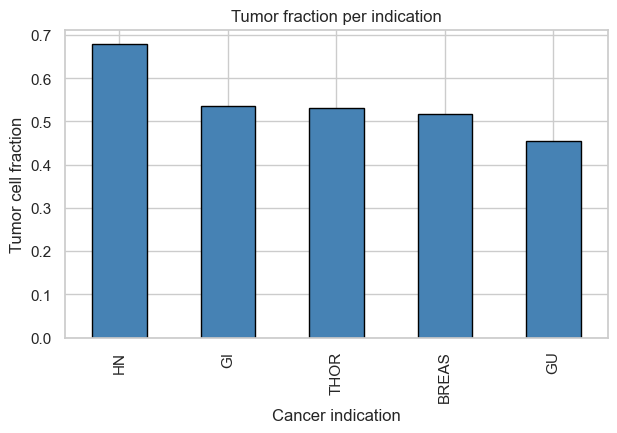

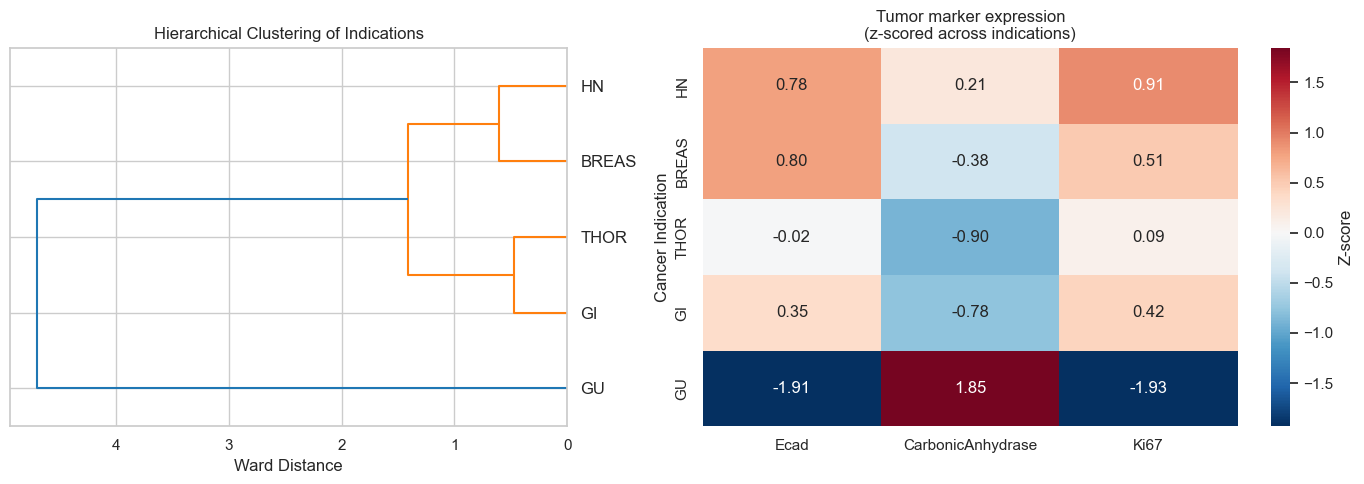

In [8]:
# 1. Tumor fraction per indication

counts = (
    adata.obs.groupby('Indication', observed=True)['celltypes']
    .value_counts()
    .unstack(fill_value=0)
)

tumor_fraction = counts['Tumor'] / counts.sum(axis=1)


tumor_fraction = tumor_fraction.sort_values(ascending=False)

plt.figure(figsize=(7, 4))

tumor_fraction.plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

plt.ylabel('Tumor cell fraction')
plt.xlabel('Cancer indication')
plt.title('Tumor fraction per indication')




# 2. Mean Ecad / CarbonicAnhydrase / Ki67 expression in Tumor cells


markers = ['Ecad', 'CarbonicAnhydrase', 'Ki67']

marker_df = pd.DataFrame(
    index=sorted(adata.obs['Indication'].unique())
)

for marker in markers:

    idx = np.where(adata.var['marker'] == marker)[0][0]

    marker_df[marker] = (
        pd.DataFrame({
            'Indication': adata.obs['Indication'],
            'Expression': adata.layers['exprs'][:, idx]
        })
        .loc[adata.obs['celltypes'] == 'Tumor']
        .groupby('Indication', observed=True)['Expression']
        .mean()
    )

print("Mean arcsinh expression in Tumor cells:")
display(marker_df)

linkage_matrix = linkage(
    marker_df,
    method='ward'
)


zdf = pd.DataFrame(
    zscore(marker_df.values, axis=0),
    index=marker_df.index,
    columns=marker_df.columns
)

fig, (ax_dendro, ax_heat) = plt.subplots(
    1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 1.2]}
)

dendro = dendrogram(
    linkage_matrix, labels=marker_df.index.tolist(), orientation="left", ax=ax_dendro
)
ax_dendro.set_title("Hierarchical Clustering of Indications")
ax_dendro.set_xlabel("Ward Distance")

reordered_zdf = zdf.iloc[dendro["leaves"][::-1]]

sns.heatmap(
    reordered_zdf,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    ax=ax_heat,
    cbar_kws={"label": "Z-score"},
)
ax_heat.set_title("Tumor marker expression\n(z-scored across indications)")
ax_heat.set_ylabel("Cancer Indication")

plt.tight_layout()
plt.show()

There are two visible clusters: GI/THOR and BREAS/HN, while GU is clearly separated from the other indications. 

Marker profile of GI/THOR cluster with relatively low CarbonicAnhydrase expression and moderate Ecad and Ki67 levels, suggests a tumour phenotype with limited metabolic adaptation and intermediate epithelial and proliferative activity; the BREAS/HN cluster shows relatively high Ecad and Ki67 expression and low CarbonicAnhydrase levels, suggesting a more epithelial and highly proliferative tumour state, relying less on changed metabolism; finally, GU exhibits elevated CarbonicAnhydrase alongside reduced Ecad and Ki67 expression, indicating a metabolically adapted phenotype associated with acidic or hypoxic microenvironments, together with reduced epithelial adhesion and lower proliferative activity.

## TASK 4

My chosen criterium is the the image that displayed the highest CD8/Tumor cell ratio.

In [9]:
adata.obsm['spatial'] = adata.obs[['Pos_X', 'Pos_Y']].values

print(f"Cells: {adata.n_obs:,}  |  Images: {adata.obs['image'].nunique()}")
print(f"Spatial coords shape: {adata.obsm['spatial'].shape}")
print(f"X range: [{adata.obs['Pos_X'].min():.1f}, {adata.obs['Pos_X'].max():.1f}] um")
print(f"Y range: [{adata.obs['Pos_Y'].min():.1f}, {adata.obs['Pos_Y'].max():.1f}] um")

Cells: 253,433  |  Images: 132
Spatial coords shape: (253433, 2)
X range: [0.0, 639.1] um
Y range: [0.3, 598.6] um


In [10]:
img_stats = adata.obs.groupby('image', observed=True).agg(
    n_cells=('Pos_X', 'count'),
    x_range=('Pos_X', lambda x: x.max() - x.min()),
    y_range=('Pos_Y', lambda x: x.max() - x.min()),
    indication=('Indication', 'first')
)

print("\nImages with most cells:")
print(img_stats.nlargest(5, 'n_cells')[['n_cells', 'indication']].to_string())


Images with most cells:
                                                                     n_cells indication
image                                                                                  
IMMUcan_Batch20210921_LUNG_10041543-LUNG-VAR-TIS-01-IMC-01_003.tiff     5152       THOR
IMMUcan_Batch20210921_UPSTREAM_S-210622-00014_004.tiff                  3746         HN
IMMUcan_Batch20210701_UPSTREAM_S-210510-00068_001.tiff                  3488         HN
IMMUcan_Batch20210304_10070084-SPECT-VAR-TIS-01-IMC-01_002.tiff         3439         GI
IMMUcan_Batch20210701_S-210531-00020_001.tiff                           3342      BREAS


In [11]:
image_counts = adata.obs.groupby(['image', 'cell_labels']).size().unstack(fill_value=0)

qualifying_images = image_counts[image_counts['Tumor'] >= 100].copy()

qualifying_images['cd8_tumor_ratio'] = qualifying_images['CD8'] / qualifying_images['Tumor']

image_id = qualifying_images['cd8_tumor_ratio'].idxmax()
image_value = qualifying_images.loc[image_id, 'cd8_tumor_ratio']

print(f"Image ID: {image_id}")
print(f"(CD8/Tumor Ratio): {image_value:.4f}")

Image ID: IMMUcan_Batch20210701_10075013-SPECT-VAR-TIS-UNST-03_002.tiff
(CD8/Tumor Ratio): 2.6138


In [12]:
adata_img = adata[adata.obs['image'] == image_id].copy()
coords = adata_img.obsm['spatial']
coords

array([[8.85000000e+01, 4.00000000e-01],
       [2.45266667e+02, 4.66666667e-01],
       [1.03571429e+02, 1.20408163e+00],
       ...,
       [3.20272727e+02, 5.98227273e+02],
       [3.31312500e+02, 5.97781250e+02],
       [4.03444444e+02, 5.97944444e+02]], shape=(2080, 2))

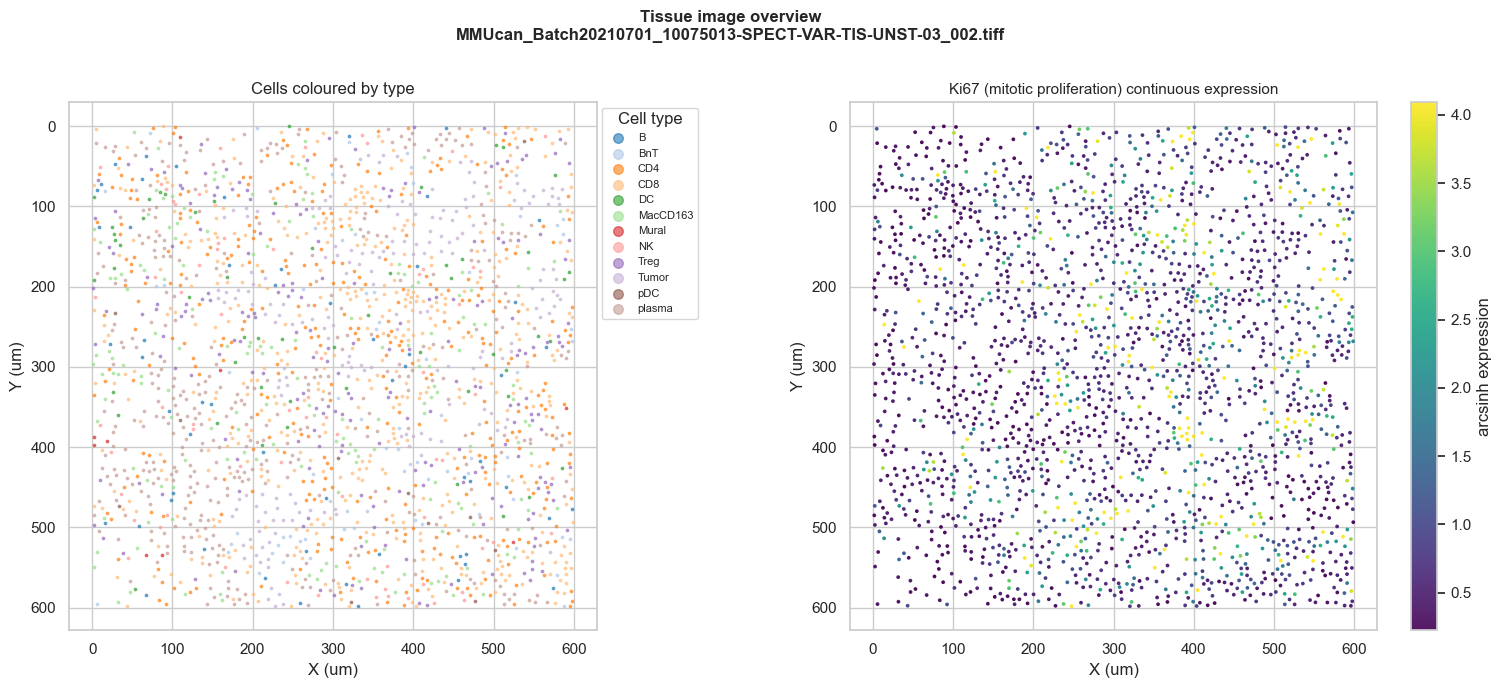

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

cell_types = sorted(adata_img.obs['celltypes'].unique())
palette = dict(zip(cell_types, sns.color_palette('tab20', len(cell_types))))

for ct in cell_types:
    c = coords[adata_img.obs['celltypes'] == ct]
    axes[0].scatter(c[:, 0], c[:, 1], s=3, alpha=0.6,
               color=palette[ct], label=ct, rasterized=True)

axes[0].set_aspect('equal')
axes[0].set_title('Cells coloured by type')
axes[0].set_xlabel('X (um)')
axes[0].set_ylabel('Y (um)')
axes[0].invert_yaxis()
axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8,
          markerscale=4, title='Cell type')

midx = np.where(adata_img.var['marker'] == 'Ki67')[0]
if len(midx) == 0:
    axes[1].text(0.5, 0.5, 'Ki67 not found', transform=axes[1].transAxes,
            ha='center', va='center')
else:
    expr = adata_img.layers['exprs'][:, midx[0]]
    sort_idx = np.argsort(expr)
    sc = axes[1].scatter(
        coords[sort_idx, 0], coords[sort_idx, 1],
        c=expr[sort_idx], cmap='viridis',
        s=3, alpha=0.9, rasterized=True,
        vmin=np.percentile(expr, 5), vmax=np.percentile(expr, 95)
    )
    plt.colorbar(sc, ax=axes[1], label='arcsinh expression')
    axes[1].set_aspect('equal')
    axes[1].invert_yaxis()
    axes[1].set_title('Ki67 (mitotic proliferation) continuous expression', fontsize=11)
    axes[1].set_xlabel('X (um)')
    axes[1].set_ylabel('Y (um)')

plt.suptitle(f"Tissue image overview\n{image_id[-60:]}\n",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Although we can see some overlap between the expression of Ki67 and the cell type, the signal is not prominent enough to deduce conclusions.

Additional tests to showcase the distribution will be conducted: violin plot of the Ki67 expression over the cell types

Quantified Expression Statistics per Cell Type:
               mean    median       std
Cell Type                              
pDC        1.992937  1.575212  1.441956
Tumor      1.834467  1.177991  1.557017
BnT        1.760047  1.212535  1.433403
Treg       1.184891  0.658297  1.240870
CD4        1.115767  0.688862  1.048691
CD8        1.104674  0.637955  1.118395
B          1.075268  0.744836  0.902345
plasma     1.048047  0.605950  1.102639
MacCD163   0.795736  0.480771  0.991604
NK         0.738540  0.503071  0.757126
DC         0.718315  0.443502  0.933468
Mural      0.377196  0.294169  0.297260


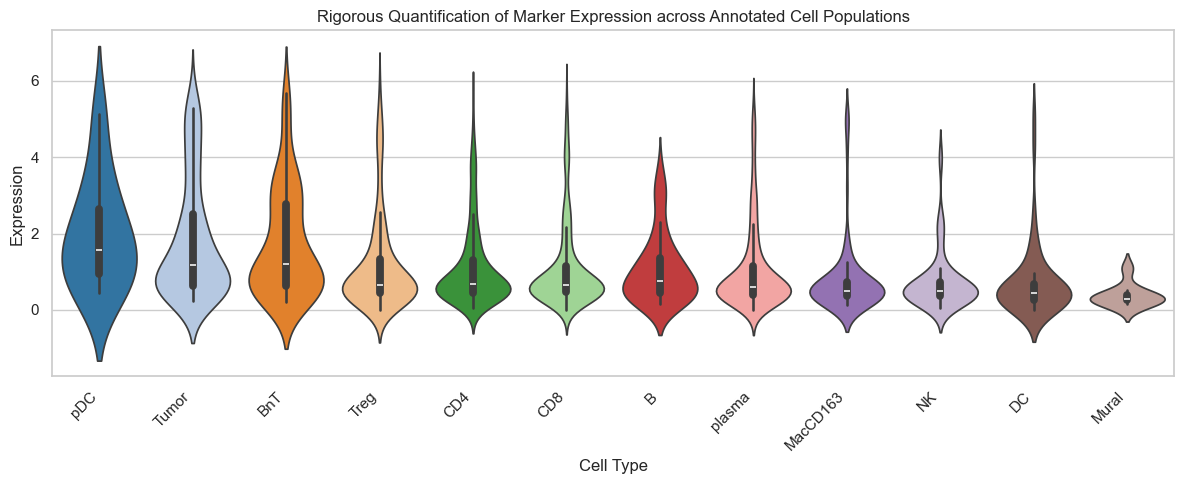

In [14]:
midx = np.where(adata_img.var['marker'] == 'Ki67')[0][0]
marker_expr = adata_img.layers['exprs'][:, midx]

df_spatial = pd.DataFrame({
    'Cell Type': adata_img.obs['celltypes'],
    'Expression': marker_expr
})

expression_stats = df_spatial.groupby('Cell Type')['Expression'].agg(['mean', 'median', 'std']).sort_values(by='mean', ascending=False)
print("Quantified Expression Statistics per Cell Type:")
print(expression_stats)

plt.figure(figsize=(12, 5))
sns.violinplot(data=df_spatial, x='Cell Type', y='Expression', order=expression_stats.index, palette='tab20')
plt.xticks(rotation=45, ha='right')
plt.title('Rigorous Quantification of Marker Expression across Annotated Cell Populations')
plt.tight_layout()
plt.show()

As can be seen in this plot: the Ki67 marker cannot be assigned uniquely to one cell type.


### Interpretation


the continuous expression of Ki67 isn't restricted to a specific phenotype. Looking closer to the distribution on the violin plot we observe, that it exhibits a widespread expression in the full range of cells - effectively refuting the notion that it is a purely tumor-restricted phenotype.

## TASK 5

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


  0%|          | 0/200 [00:00<?, ?/s]


================ RESULTS ================

Top 2 cell types enriched around Tumor:
BnT   -0.178881
DC    -1.568430
Name: Tumor, dtype: float64

Tumor self-enrichment (z-score):
41.744923546529044

CD8 enrichment around Tumor:
-1.8251688024329542


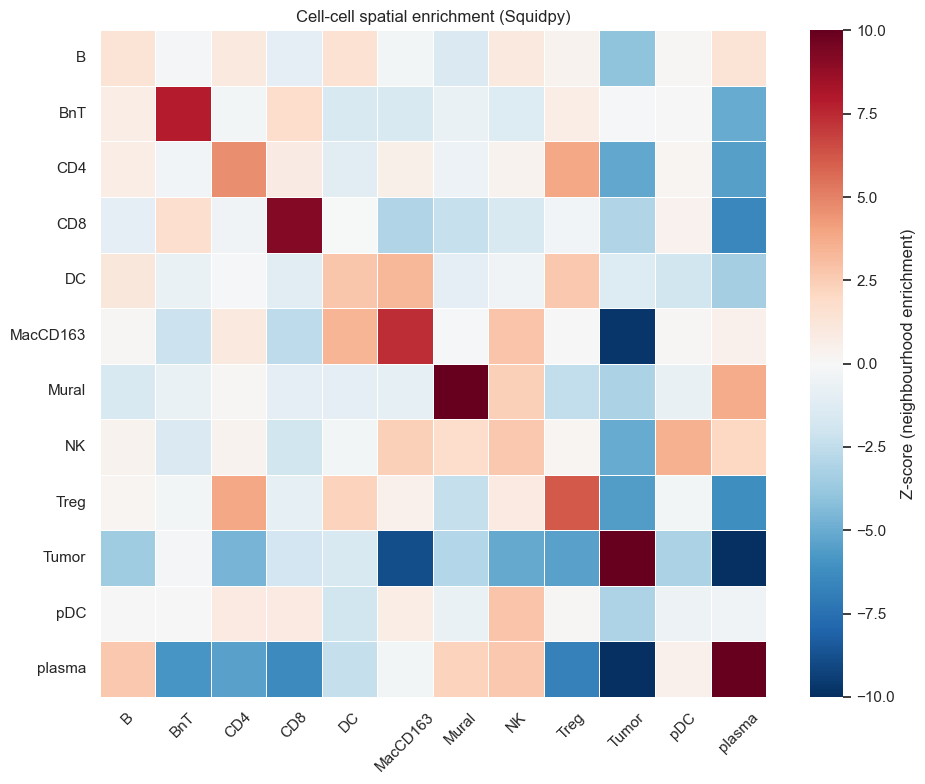

In [15]:
adata_s = adata[adata.obs['image'] == "IMMUcan_Batch20210701_10075013-SPECT-VAR-TIS-UNST-03_002.tiff"].copy()

adata_s.obsm['spatial'] = np.column_stack( [adata_s.obs['Pos_X'].values,
adata_s.obs['Pos_Y'].values])


sq.gr.spatial_neighbors(
    adata_s,
    coord_type='generic',
    spatial_key='spatial',
    n_neighs=10
)


sq.gr.nhood_enrichment(
    adata_s,
    cluster_key='celltypes',
    n_perms=200,
    seed=42
)



z = adata_s.uns['celltypes_nhood_enrichment']['zscore']

cell_types = adata_s.obs['celltypes'].cat.categories.tolist()

z_df = pd.DataFrame(z, index=cell_types, columns=cell_types)


tumor_row = z_df.loc['Tumor'].drop('Tumor')
tumor_row_sorted = tumor_row.sort_values(ascending=False)

top2 = tumor_row_sorted.head(2)

tumor_self = z_df.loc['Tumor', 'Tumor']

cd8_val = z_df.loc['Tumor', 'CD8'] if 'CD8' in z_df.columns else None


print("\n================ RESULTS ================\n")

print("Top 2 cell types enriched around Tumor:")
print(top2)

print("\nTumor self-enrichment (z-score):")
print(tumor_self)

print("\nCD8 enrichment around Tumor:")
print(cd8_val)


plt.figure(figsize=(10, 8))

sns.heatmap(
    z_df,
    cmap='RdBu_r',
    center=0,
    vmin=-10, vmax=10,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Z-score (neighbourhood enrichment)'}
)

plt.title("Cell-cell spatial enrichment (Squidpy)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Top 2 cell types enriched next to Tumor are BnT(-0.178881) and DC(-1.568430). Tumor self-enrichment is very strong (z = 41.74), indicating strong spatial clustering. CD8 cells are depleted around Tumor (z = -1.83), suggesting reduced cytotoxic T cell infiltration in this image.

## TASK 6

In [16]:
all_image_fractions = []
tumor_counts = []
    # lista liczby komorek nowotworowych w kolejntcg zdjeciach

grouped = adata.obs.groupby('image', observed=True)

for name, group in grouped:

    # print(f"Group: {name}")
    adata_img = adata[adata.obs['image'] == name].copy()

    coords = adata_img.obsm['spatial']
    cell_types = adata_img.obs['celltypes']

    tumor_coords = coords[adata_img.obs['celltypes'].values == 'Tumor']
    n_tumor_cells = tumor_coords.shape[0]

    if  n_tumor_cells == 0:
        print(f'{name} No  tumor cells for this image')
        continue

    tree = KDTree(coords)
    distances, idxs = tree.query(tumor_coords, k=11)
    neighbor_idxs = idxs[:, 1:].flatten()

    neighbor_types = cell_types.iloc[neighbor_idxs]
    image_fractions = neighbor_types.value_counts(normalize=True)

  
    image_fractions.name = name
    all_image_fractions.append(image_fractions)
    tumor_counts.append(n_tumor_cells)

fractions_df = pd.concat(all_image_fractions, axis=1).T.fillna(0.0)
    # laczymy dane z wszystkich zdjec

weights = np.array(tumor_counts)

weighted_means = np.average(fractions_df, axis=0, weights=weights)
    # srednia wazona

tumor_env = pd.Series(weighted_means, index=fractions_df.columns)

print(tumor_env)

IMMUcan_Batch20210506_10032400-GU-VAR-TIS-01-IMC-01_003.tiff No  tumor cells for this image
IMMUcan_Batch20210506_10068594-SPECT-VAR-TIS-01-IMC-01_003.tiff No  tumor cells for this image
IMMUcan_Batch20220309_10088313-SPECT-VAR-TIS-01-IMC-01_004.tiff No  tumor cells for this image
IMMUcan_Batch20220609_10089094-SPECT-VAR-TIS-01-IMC-01_001.tiff No  tumor cells for this image
IMMUcan_Batch20220908_10089829-SPECT-VAR-TIS-UNST-03_001.tiff No  tumor cells for this image
celltypes
Tumor         0.848316
Neutrophil    0.015659
CD8           0.034502
MacCD163      0.025559
DC            0.010142
CD4           0.014761
plasma        0.004496
NK            0.001505
Mural         0.024987
HLADR         0.008236
B             0.001315
Treg          0.008914
pDC           0.000584
BnT           0.001024
dtype: float64


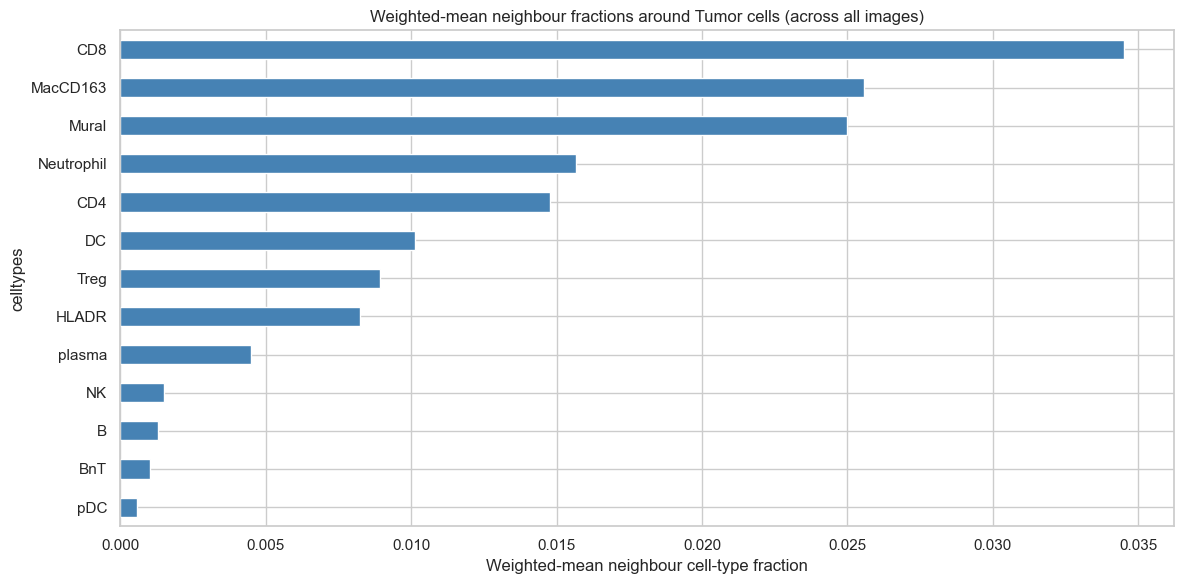

The non-Tumor cell type most frequently adjacent to Tumor cells is: CD8


In [17]:
non_tumor_env = tumor_env.drop('Tumor', errors='ignore').sort_values(ascending=False)

plt.figure(figsize=(12, 6))
non_tumor_env.plot(kind="barh", color="steelblue")
plt.xlabel("Weighted-mean neighbour cell-type fraction")
plt.title("Weighted-mean neighbour fractions around Tumor cells (across all images)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

if not non_tumor_env.empty:
    most_freq = non_tumor_env.index[0]
    print(f"The non-Tumor cell type most frequently adjacent to Tumor cells is: {most_freq}")
else:
    print("No non-Tumor cell types found adjacent to Tumor cells.")

The CD8 cells most frequently are present next to tumor cells. The CD8 is marker for the cytotoxic t cells.

Their abundant presence next to tumor cells indicates that in these images the tumor is being actively targeted by the immune system.

## TASK 7

The file chosen is the same as in task 4: IMMUcan_Batch20210701_10075013-SPECT-VAR-TIS-UNST-03_002.tiff

In [18]:
image_id

'IMMUcan_Batch20210701_10075013-SPECT-VAR-TIS-UNST-03_002.tiff'

In [19]:
adata_img = adata[adata.obs['image'] == image_id].copy()
adata_img.layers['exprs'].shape

(2080, 40)

In [20]:
tumor_cells = adata_img[adata_img.obs['cell_labels'] == 'Tumor'].copy()

#### Possible markers to use :


1 HistoneH3 2 SMA 3 CD16 4 CD38 6 CD27 7 CD15 11 CD20 13 Ido1 18 PDGFRb 20 GrzB 25 ICOS 28 CD33 30 VISTA 31 CD40 33 CD14 35 CD303 36 CD206

34 Ecad - epithelial cell adhesion; loss of ecad is an indicator of metastatic potential <br>
29 Ki67 - assosiated with cellular proliferation; differentiates actively growing from passive cells <br>
37 cleavedPARP - segregates apoptotic or dying cell populations <br>
27 CarbonicAnhydrase - often upregulated in hypoxia enviroments; may indicate those populations that are resistant to radio or chemotherapy <br>
38 DNA1 - staining dna? <br>
39 DNA2 - staining dna?

__________________________

12 CD68 - identify tumor associated macrophages (tams) <br>
9 CD163 - marker for immunosuppressive tams; high cd68/cd163 indicates poor prognosis <br>
16 CD11c - identifies dc populations <br>
5 HLADR - mhc II marker; targets antugen-presenting cells (dc, b cells, activated t cells); lack signifies immune evasion <br>
0 MPO - a neutrofil and granylocyte marker <br>
10 B2M - mhc i marker; may indicate immune-evasive tumor subpopulations (loss od mhvc i populations)

____________________
17 PD1 - programmed cell death <br>
21 PDL1 - immune-checkpoint presenting cell populations 15 LAG3 - <br>
32 CD4 - helper t cells <br>
22 TCF7 - tf marker; favourable prognosis on immune checkpoint blockade <br>
26 CD8a - cytotoxic t cells <br>
24 FOXP3 - tf for regulatory t cells \ 19 CD7 - t cells and nk marker <br>
14 CD3 - t cell marker <br>
8 CD45RA - naive or differentiated effector memoru t cells <br>
23 CD45RO - memory t cells 

_________________________ chosen ____________________

ecad, ki67, cleavedparp, carbonicanhydrase, b2m cd3, cd8a - t cell infiltration cd68, cd163 - macrophages pdl1

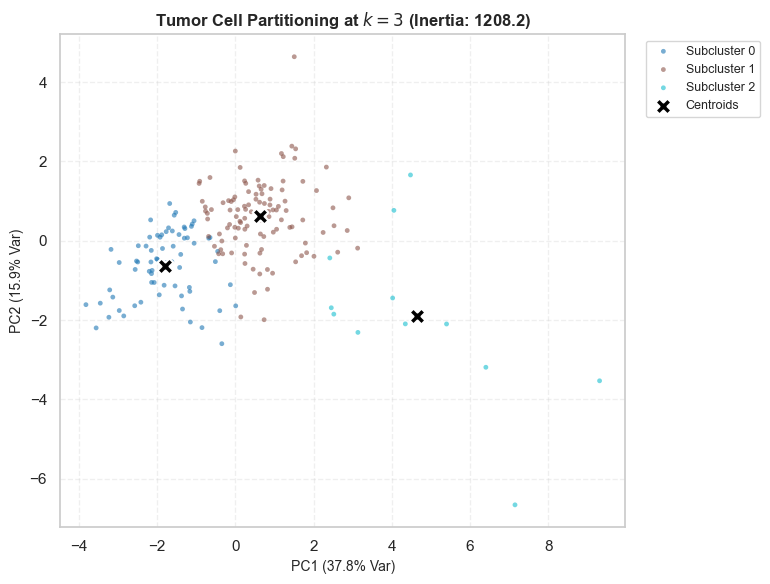

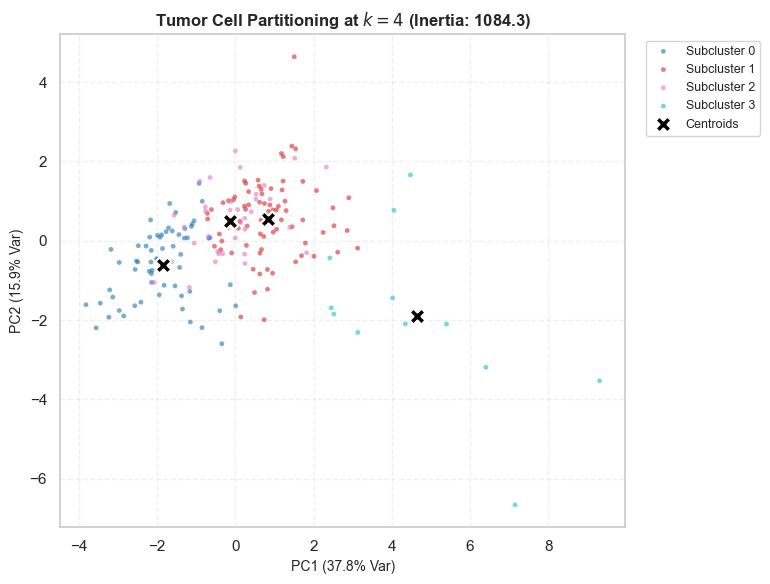

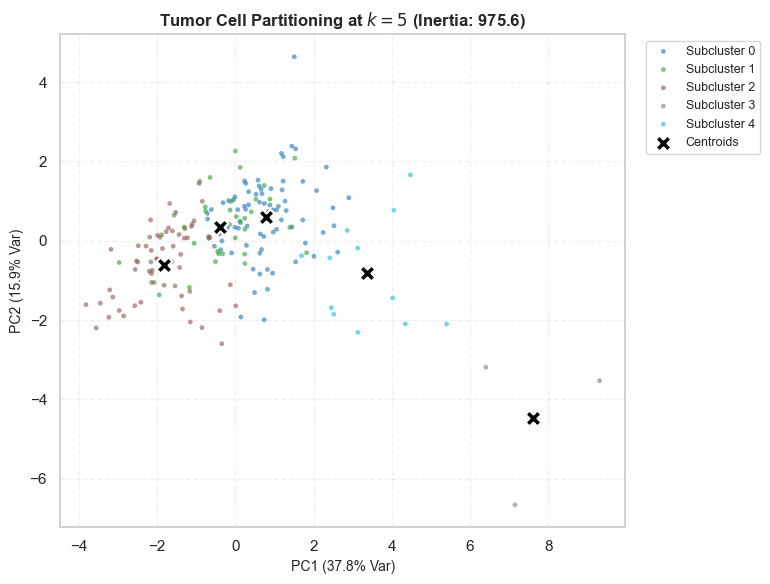

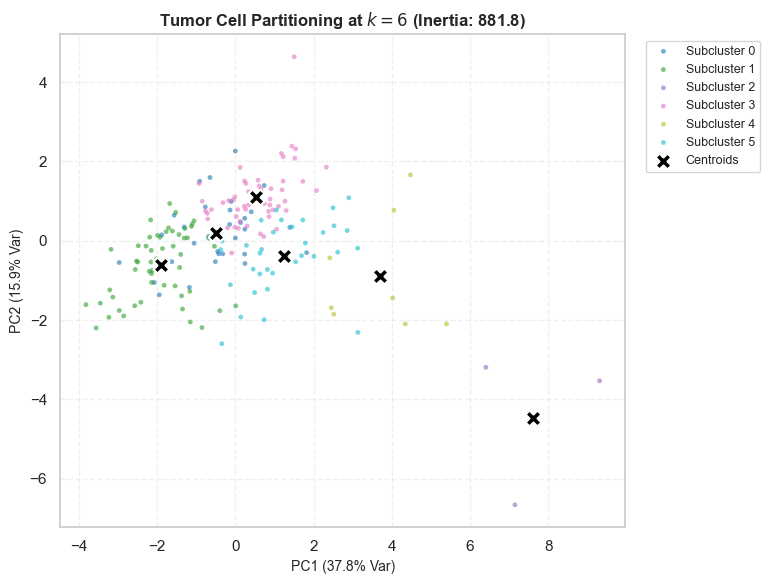

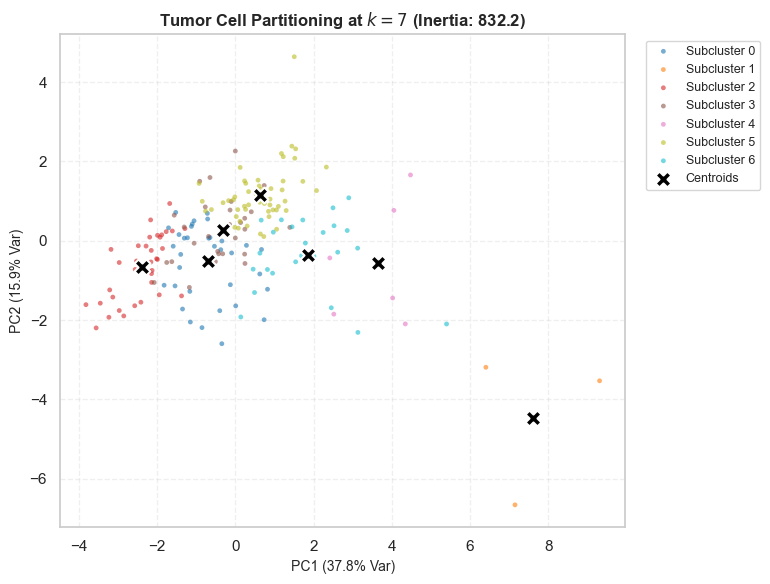

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
    # silkouette_score - computes the mean coefficient used to asses the qulity of an unsupervied clustering; how well separated the resulting clusters aka how tightly grouped they are

from sklearn.decomposition import PCA

marker_ids = [34, 29, 37, 27, 10, 14, 26, 12, 9, 21]

chosen_markers = tumor_cells.layers['exprs'][:, marker_ids]

scaler = StandardScaler()
normalised_markers = scaler.fit_transform(chosen_markers)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(normalised_markers)
variance_explained = pca.explained_variance_ratio_ * 100

k_range = [3,4,5,6,7]

recorded_k = []
inertia_values = []
silhouette_values = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    cluster = kmeans.fit(normalised_markers)
    
    recorded_k.append(k)
    inertia_values.append(cluster.inertia_)
    silhouette_values.append(silhouette_score(normalised_markers, cluster.labels_, metric='euclidean'))

    plt.figure(figsize=(8, 6))
    
    cmap = plt.cm.get_cmap('tab10', k)
    
    for cluster_idx in range(k):
        mask = (cluster.labels_ == cluster_idx)
        plt.scatter(
            X_pca[mask, 0], 
            X_pca[mask, 1], 
            s=12, 
            color=cmap(cluster_idx),
            label=f'Subcluster {cluster_idx}',
            alpha=0.6,
            edgecolors='none'
        )
        
    centroids_pca = pca.transform(kmeans.cluster_centers_)
    plt.scatter(
        centroids_pca[:, 0], 
        centroids_pca[:, 1], 
        s=130, 
        marker='X', 
        color='black', 
        edgecolors='white', 
        linewidth=1.5, 
        label='Centroids'
    )
    
    plt.title(f'Tumor Cell Partitioning at $k = {k}$ (Inertia: {kmeans.inertia_:.1f})', fontsize=12, fontweight='bold')
    plt.xlabel(f'PC1 ({variance_explained[0]:.1f}% Var)', fontsize=10)
    plt.ylabel(f'PC2 ({variance_explained[1]:.1f}% Var)', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1), frameon=True, fontsize=9)
    plt.tight_layout()
    
    plt.show()


kmeans_df = pd.DataFrame({
    'k': recorded_k,
    'inertia': inertia_values,
    'silhouette_score': silhouette_values
})

### Plotting the inertia to choose the best k

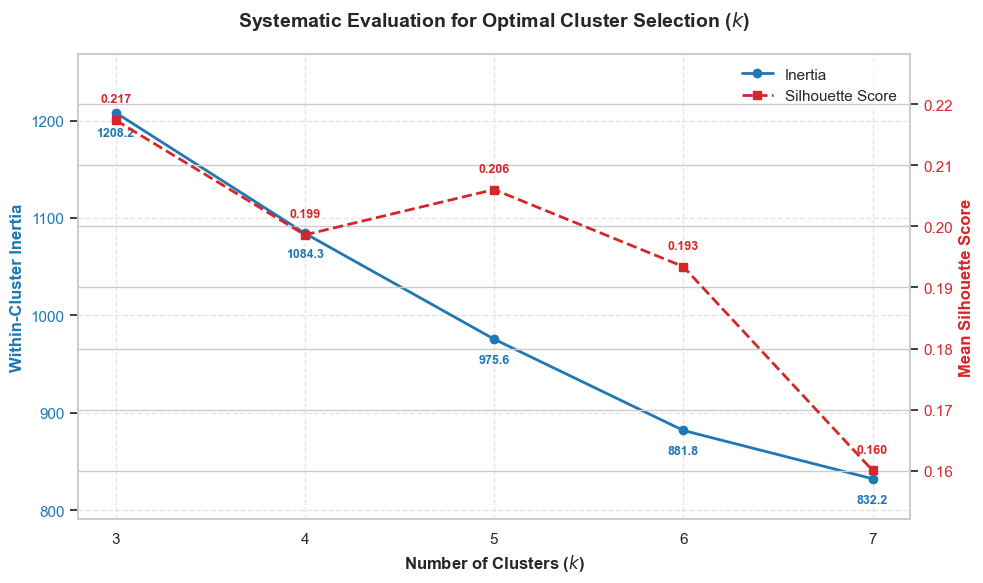

In [22]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color_inertia = '#1f77b4'  # Deep Blue
ax1.set_xlabel('Number of Clusters ($k$)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Within-Cluster Inertia', color=color_inertia, fontsize=12, fontweight='bold')
line1 = ax1.plot(kmeans_df['k'], kmeans_df['inertia'], marker='o', linestyle='-', color=color_inertia, linewidth=2, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color_inertia)
ax1.grid(True, linestyle='--', alpha=0.5)

for x, y in zip(kmeans_df['k'], kmeans_df['inertia']):
    ax1.annotate(
        f'{y:.1f}',              
        xy=(x, y), 
        xytext=(0, -15),         
        textcoords='offset points', 
        ha='center',             
        va='center', 
        fontsize=9, 
        color=color_inertia, 
        fontweight='bold'
    )

ax2 = ax1.twinx()
color_silhouette = '#d62728'  
ax2.set_ylabel('Mean Silhouette Score', color=color_silhouette, fontsize=12, fontweight='bold')
line2 = ax2.plot(kmeans_df['k'], kmeans_df['silhouette_score'], marker='s', linestyle='--', color=color_silhouette, linewidth=2, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color_silhouette)

for x, y in zip(kmeans_df['k'], kmeans_df['silhouette_score']):
    ax2.annotate(
        f'{y:.3f}',           
        xy=(x, y), 
        xytext=(0, 15),       
        textcoords='offset points', 
        ha='center', 
        va='center', 
        fontsize=9, 
        color=color_silhouette, 
        fontweight='bold'
    )

plt.xticks(k_range)

ax1.set_ylim(kmeans_df['inertia'].min() * 0.95, kmeans_df['inertia'].max() * 1.05)
ax2.set_ylim(kmeans_df['silhouette_score'].min() * 0.95, kmeans_df['silhouette_score'].max() * 1.05)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.title('Systematic Evaluation for Optimal Cluster Selection ($k$)', fontsize=14, fontweight='bold', pad=20)
fig.tight_layout()

plt.show()

In [23]:
for idx in range(5):
    if idx == 4:
        break
    print(f"delta{idx+1} between {idx+3} and {idx+4}: {kmeans_df['inertia'][idx] - kmeans_df['inertia'][idx+1]}")

delta1 between 3 and 4: 123.93214284819169
delta2 between 4 and 5: 108.68459247347232
delta3 between 5 and 6: 93.76986117543652
delta4 between 6 and 7: 49.590534646515266


Mathematically the best would be k=5, as the silhouette score is the highest, indicating optimal cluster separation.

However by analysing the rate of change in within-cluster inertia it can be seen that the most substantial compression of data occurs when when transitioning from 3 to 4 clusters.

Additionally the PCA projections confirms that moving to k=5 or k=6 merely fragments the core cellular density into arbitrary subdivisions rather than resolving isolated topologies.

The unsupervised algorithm may align with the four foundational axes of tumor heterogeneity: proliferation (Ki67), hypoxia (CarbonicAnhydrase), epithelial-mesenchymal transition (Ecad,SMA), and apoptosis (cleavedPARP).

In [24]:
# saving the chosen clustering for task 8
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
cluster = kmeans.fit(normalised_markers)
tumor_cells.obs['optimal_clusters'] = cluster.labels_

## TASK 8

In [25]:
#wyizolowac usable markers
usable_markers = tumor_cells[:, tumor_cells.var['use_channel'] == 1]

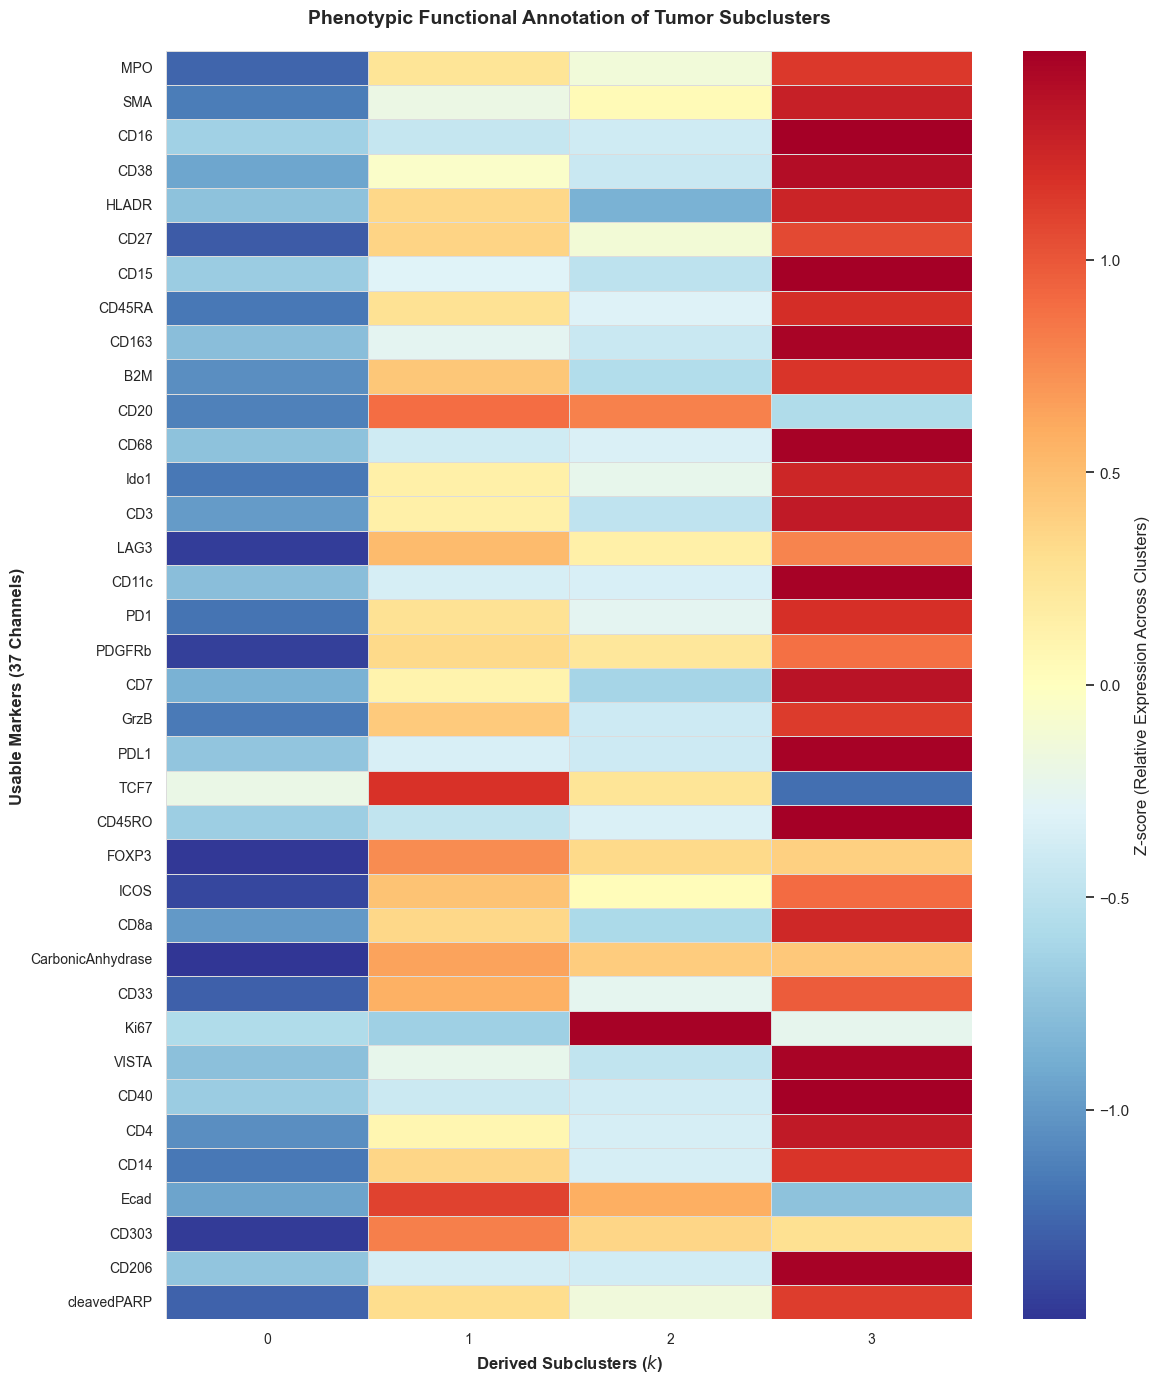

In [26]:
expression_matrix = usable_markers.layers['exprs']
marker_names = usable_markers.var['marker']
cluster_labels = usable_markers.obs['optimal_clusters'].values

df_exprs = pd.DataFrame(expression_matrix, columns=marker_names)
df_exprs['Cluster'] = cluster_labels

cluster_profiles = df_exprs.groupby('Cluster').mean().T

#the sns.heatmap doesnt have a z-score option, so i will manually compute the normalisation
row_means = cluster_profiles.mean(axis=1)
row_stds = cluster_profiles.std(axis=1)

epsilon = 1e-6
cluster_profiles_normalized = cluster_profiles.sub(row_means, axis=0).div(row_stds + epsilon, axis=0)

plt.figure(figsize=(12, 14))

sns.heatmap(
    cluster_profiles_normalized, 
    cmap='RdYlBu_r', 
    cbar_kws={'label': 'Z-score (Relative Expression Across Clusters)'},
    linewidths=0.5,
    linecolor='gainsboro'
)

plt.title('Phenotypic Functional Annotation of Tumor Subclusters', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Derived Subclusters ($k$)', fontsize=12, fontweight='bold')
plt.ylabel('Usable Markers (37 Channels)', fontsize=12, fontweight='bold')
plt.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()


### Proposed biological explanation of each cluster

#### cluster 0

- we can see a global downregulation of almost all functional markers;

- low levels of Ki67 (here: signifies not actively proliferating cells), CarbonicAnhydrase (here: the cells do not experience hypoxia), FOXP3 (here: absence of regulatory T-cell signals), ICOS (here: cells are immunologically silent)

- these cells are functionally non-responsive, metabolically inactive, unengaged by the surrounding enviroment;

- **summary:** this niche captures a stable reservoir of the tumor mass that is dormant, showing no signs of proliferative expansion, hypoxic stress, or active immune interaction;

- **non-reactive epithelial niche**

#### cluster 1

- noticable upregulation of TCF7 (a tf crucial for maintaining stemness; implies the enabaling self-renewal processes and high cellular plasticity), CD20 (indicates spatial proximity with localized humoral immune aggregates), Ecad (retaining epithelial phenotype)

- **summary:** these cells maintain epithelial phenotype yet show activation of transformation into stem-like cells with unlimited proliferation capacity directed for expansion or structural remodeling;

- **EMT niche**

#### cluster 2

- almost exclusively defined by the intense upregulation of Ki67 (here: rapid proliferation, highly mitotic growing cells);

- overall downregulation of the markers (like HLADR - here: signifies active immune evasion, CD8a - here: lack of infiltrating cytotoxic T cells),

- alongside supporting upregulation of CD20 (here: physical proximity or signal leakage from neighboring B-cells) and Ecad (here: strong retention of the cohesive epithelial architecture);

- **summary:** these cells represent the rapidly expanding core of the tumor mass, maximizing mitotic activity while excluding active cellular immunity and maintaining baseline epithelial cohesion;

- **highly-proliferative niche**

#### cluster 3

- the most intensively upregulated cluster of all;

- heavily enriched for macrophage lineage markers (CD14, CD68, CD16, CD163, CD206), antigen-presenting molecules (HLADR, B2M), immune checkpoints (PDL1, Ido1, VISTA, PD1, LAG3), and T-cell markers (CD3, CD4, CD8a),

- also shows the highest enrichment for cleavedPARP (here: explicitly denoting the activation of terminal programmed cell death pathways within these cells)

- **summary:** this niche is a highly inflamed hotspot where tumor cells are under immune attack undergoing terminal apoptotic stress;

- **immune-reactive, dying tumor cells**

## Task 9 - Cross-cohort validation

Hypothesis: "The pattern  of indication clustering by z-scored Ecad, CarbonicAnhydrase, and Ki67 expression in Tumor cells observed in the training cohort will hold in the independent test cohort."


The clustering shown as heatmap and dendrogram in Task 3 clearly separates GU, GI/THOR, and BREAST/HN indications (and is more informative than, for example tumor cell fraction per indication). This pattern is expected to hold in the test cohort because it reflects biologically meaningful differences in epithelial state(Ecad), proliferation(Ki67), and metabolic adaptation (CA) captured by these markers.


REASONS - CHARACTERISTIC MARKERS:


Genitourinary (GU) tumors are expected to show higher carbonic anhydrase due to adaptation to hypoxic and acidic microenvironments. Breast (BREAST) tumors are expected to show higher Ecad, consistent with epithelial features of invasive ductal carcinoma (IDC) - the most common type of breast cancer. Head and neck (HN) tumors are generally characterized by higher Ki67, reflecting increased proliferation.

Thoracic (THOR) tumors may show reduced carbonic anhydrase expression; for example, CA IV is significantly downregulated in non-small cell lung cancer (NSCLC) tissues and cell lines (https://doi.org/10.3892/ol.2017.6740). Gastrointestinal (GI) tumors can also show reduced CA expression in specific contexts; for example, CA9 can be low or lost in gastric cancer (https://doi.org/10.1136/gut.2004.047340).

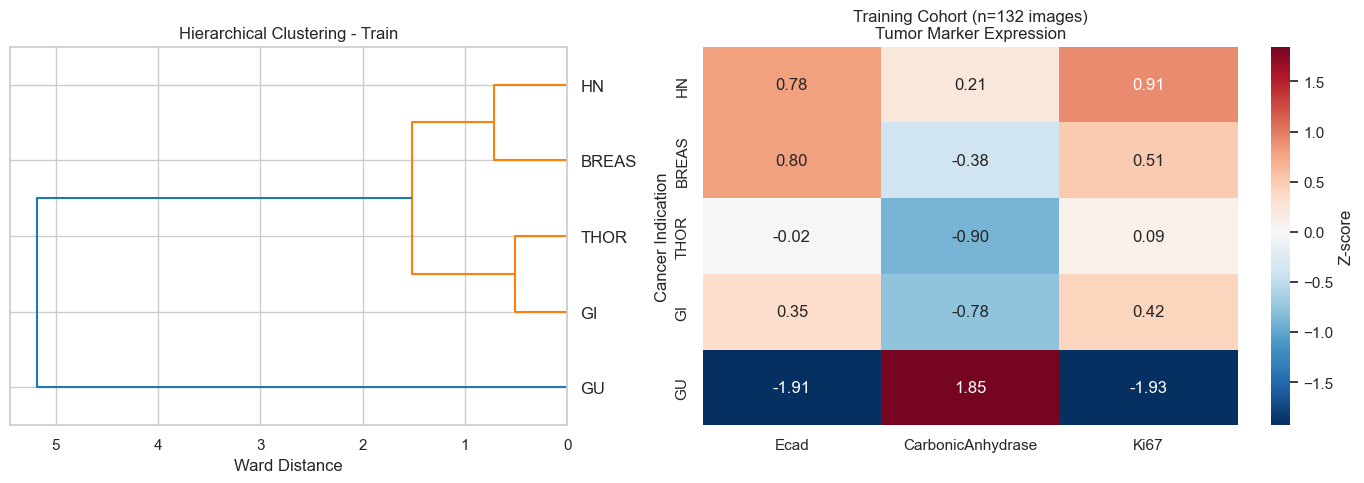

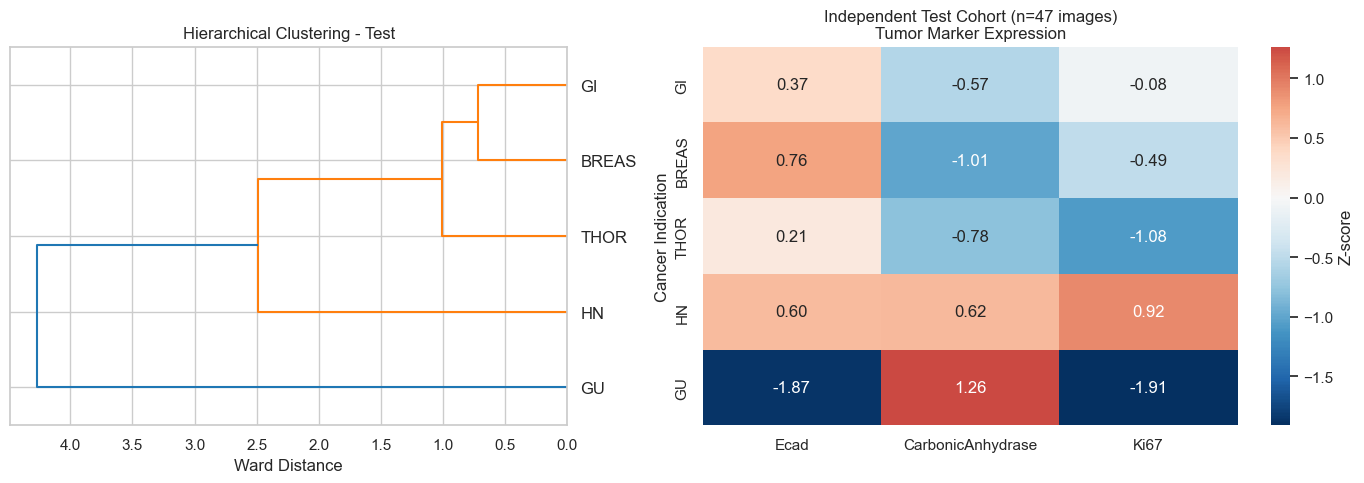

In [27]:
TEST_PATH = "data/test_adata.h5ad"

adata_train = ad.read_h5ad(DATA_PATH)
adata_test = ad.read_h5ad(TEST_PATH)

adata_test = adata_test[adata_test.obs["celltypes"] != "undefined"].copy()

markers = ["Ecad", "CarbonicAnhydrase", "Ki67"]

def get_marker_means(adata, markers):
    marker_df = pd.DataFrame(
        index=sorted(adata.obs['Indication'].unique())
    )

    for marker in markers:
        idx = np.where(adata.var["marker"] == marker)[0][0]

        marker_df[marker] = (
            pd.DataFrame({
                'Indication': adata.obs['Indication'],
                'Expression': adata.layers['exprs'][:, idx]
            })
            .loc[adata.obs['celltypes'] == 'Tumor']
            .groupby('Indication', observed=True)['Expression']
            .mean()
        )
    return marker_df

train_means = get_marker_means(adata_train, markers)
test_means = get_marker_means(adata_test, markers)

train_z = pd.DataFrame(
    (train_means - train_means.mean()) / train_means.std(ddof=0),
    index=train_means.index,
    columns=train_means.columns,
)

# To maintain consistency the test set is scaled with the parameters of the training set
test_z = pd.DataFrame(
    (test_means - train_means.mean()) / train_means.std(ddof=0),
    index=test_means.index,
    columns=test_means.columns,
)

fig, (ax_dendro, ax_heat) = plt.subplots(
    1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 1.2]}
)

linkage_train = linkage(train_z, method="ward")

dendro_train = dendrogram(
    linkage_train, labels=train_z.index.tolist(), orientation="left", ax=ax_dendro
)
ax_dendro.set_title("Hierarchical Clustering - Train")
ax_dendro.set_xlabel("Ward Distance")

reordered_train_z = train_z.iloc[dendro_train["leaves"][::-1]]

sns.heatmap(
    reordered_train_z,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    ax=ax_heat,
    cbar_kws={"label": "Z-score"},
)
ax_heat.set_title("Training Cohort (n=132 images)\nTumor Marker Expression")
ax_heat.set_ylabel("Cancer Indication")

plt.tight_layout()
plt.show()


fig, (ax_dendro, ax_heat) = plt.subplots(
    1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 1.2]}
)

linkage_test = linkage(test_z, method="ward")

dendro_test = dendrogram(
    linkage_test, labels=test_z.index.tolist(), orientation="left", ax=ax_dendro
)
ax_dendro.set_title("Hierarchical Clustering - Test")
ax_dendro.set_xlabel("Ward Distance")

reordered_test_z = test_z.iloc[dendro_test["leaves"][::-1]]

sns.heatmap(
    reordered_test_z,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    ax=ax_heat,
    cbar_kws={"label": "Z-score"},
)
ax_heat.set_title("Independent Test Cohort (n=47 images)\nTumor Marker Expression")
ax_heat.set_ylabel("Cancer Indication")

plt.tight_layout()
plt.show()

Although the characteristics described in the hypothesis were largely preserved, other changes in marker expression substantially altered the final clustering pattern.


The proposed profile held for GU tumors and mostly for GI tumors, but BREAS showed lower CarbonicAnhydrase (-0.38 → -1.01) and Ki67 (0.51 → -0.49), THOR showed lower Ki67 (0.09 → -1.08), and HN showed higher CarbonicAnhydrase (0.21 → 0.62).


These shifts are consistent with the literature, which shows that Ki67 and CarbonicAnhydrase expression vary considerably depending on cancer subtype, tissue context, and disease stage: <br>
for example, high Ki67 is observed in only ~43% of breast cancers (https://doi.org/10.7759/cureus.38351), high CAIX expression in breast cancer ranges from 8% to 91% (https://doi.org/10.3389/fmed.2023.1087270), only ~49% of thoracic tumors are Ki67-positive (https://doi.org/10.1038/sj.bjc.6602233), and ~56% of head and neck tumors show high CA-9 expression (doi: 10.1007/s00405-011-1488-z). 
 
In contrast, the GU profile remained relatively stable, with generally low Ki67 expression reported across GU cancers such as prostate cancer (https://doi.org/10.1038/s41379-019-0268-y).
 
This suggests that Ki67 and CarbonicAnhydrase are too variable to serve as robust indication-level clustering markers across BREAS, THOR, HN, and GI tumors. More reliable clustering would likely require additional markers or using cancer subtypes as indications. Ecad still appears useful for separating BREAS/HN from THOR/GI tumors. Therefore, the current marker panel seems most effective for identifying GU cancers rather than classifying all indications.